In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/vehicle_pairs_dataset.zip ./vehicle_pairs_dataset.zip

In [3]:
!mkdir ./dataset

In [4]:
!unzip ./vehicle_pairs_dataset.zip -d ./dataset

Streaming output truncated to the last 5000 lines.
  inflating: ./dataset/pairs/images/4839ae72a19cfa0d.jpg  
  inflating: ./dataset/pairs/images/e2997005cc8ec04c.webp  
  inflating: ./dataset/pairs/images/1273baab495f43e9.jpg  
  inflating: ./dataset/pairs/images/ae7979235c6b4298.webp  
  inflating: ./dataset/pairs/images/146169eb976a9467.webp  
  inflating: ./dataset/pairs/images/31ba580b52936a43.webp  
  inflating: ./dataset/pairs/images/6ce96f13ed4c297a.jpg  
  inflating: ./dataset/pairs/images/3986d6da992bc8a1.jpg  
  inflating: ./dataset/pairs/images/fd6701225ded77de.jpg  
  inflating: ./dataset/pairs/images/acc039f4325ceb36.jpg  
  inflating: ./dataset/pairs/images/b29acee9d973cf41.webp  
  inflating: ./dataset/pairs/images/1412b4f7ead4dd1a.jpg  
  inflating: ./dataset/pairs/images/e3bb4945a935b618.jpg  
  inflating: ./dataset/pairs/images/b017d1b7fe5b4718.webp  
  inflating: ./dataset/pairs/images/6cd94a59e9dd1d5b.webp  
  inflating: ./dataset/pairs/images/f9b530a850c8c00b.webp

# Image-to-Vector Encoder for Cosine Similarity Search

Trains a **siamese** encoder so that vehicle images map to a 256-D vector space where

$$\text{cos}(\mathbf{e}_a, \mathbf{e}_b) = \frac{\sum_i e_{a,i}\, e_{b,i}}{\lVert\mathbf{e}_a\rVert \cdot \lVert\mathbf{e}_b\rVert}$$

is **high** for two photos of the same vehicle and **low** otherwise.

- **Architecture** matches `ui/encoder.py` / `storage` pipeline → trained weights are a drop-in `encoder.pth`.
- **Dataset** comes from `notebooks/dataset/pairs/` (built by `BuildPairsDataset.ipynb`).
- **Loss**: `CosineEmbeddingLoss` with margin on negatives.

In [5]:
%pip install -q torch torchvision pillow tqdm pandas scikit-learn matplotlib

In [6]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Configuration

In [21]:
# Dataset root produced by BuildPairsDataset.ipynb
DATA_ROOT = Path("./dataset/pairs")

TRAIN_CSV = DATA_ROOT / "pairs_train_clean.csv"
VAL_CSV   = DATA_ROOT / "pairs_val_clean.csv"
TEST_CSV  = DATA_ROOT / "pairs_test_clean.csv"

# Model / training
IMG_SIZE     = 256
LATENT_DIM   = 256
BATCH_SIZE   = 128
NUM_WORKERS  = 0
EPOCHS       = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MARGIN       = 0.3        # CosineEmbeddingLoss margin for negatives

CKPT_DIR  = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)
BEST_PATH = CKPT_DIR / "encoder_best.pth"
FINAL_PATH = CKPT_DIR / "encoder.pth"

print("Train:", TRAIN_CSV)
print("Val:  ", VAL_CSV)
print("Test: ", TEST_CSV)

Train: dataset/pairs/pairs_train_clean.csv
Val:   dataset/pairs/pairs_val_clean.csv
Test:  dataset/pairs/pairs_test_clean.csv


## Preprocessing

`Letterbox` preserves aspect ratio (same logic as `ui/encoder.py`). For training we also add light augmentations on each image **independently** — different crops/flips on the two photos of a positive pair force the encoder to learn invariances.

In [22]:
class Letterbox:
    """Resize keeping aspect ratio, pad to a square (same as inference pipeline)."""
    def __init__(self, size, fill=0):
        self.size = size
        self.fill = fill
    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        scale = min(self.size / w, self.size / h)
        nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
        img = img.resize((nw, nh), Image.BILINEAR)
        new_img = Image.new("RGB", (self.size, self.size), (self.fill,) * 3)
        new_img.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))
        return new_img

train_tf = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    Letterbox(IMG_SIZE),
    transforms.ToTensor(),
])

## Pair dataset

In [23]:
class PairsDataset(Dataset):
    """
    Reads a pairs CSV with columns: path_a, path_b, label, vehicle_id_a, vehicle_id_b.
    Paths are resolved relative to `root` (the directory containing the CSV).
    Bad / missing files are skipped lazily by returning the next valid index.
    """
    def __init__(self, csv_path: Path, root: Path, transform):
        self.df = pd.read_csv(csv_path)
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load(self, rel_path: str) -> torch.Tensor:
        img = Image.open(self.root / rel_path).convert("RGB")
        return self.transform(img)

    def __getitem__(self, idx):
        for _ in range(5):
            row = self.df.iloc[idx]
            try:
                a = self._load(row["path_a"])
                b = self._load(row["path_b"])
                label = int(row["label"])
                return a, b, label
            except (FileNotFoundError, OSError, Image.UnidentifiedImageError):
                idx = (idx + 1) % len(self.df)
        raise RuntimeError("Too many broken images in a row")

train_ds = PairsDataset(TRAIN_CSV, DATA_ROOT, train_tf)
val_ds   = PairsDataset(VAL_CSV,   DATA_ROOT, eval_tf)
test_ds  = PairsDataset(TEST_CSV,  DATA_ROOT, eval_tf)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

_loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True, **_loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

Train: 12306 | Val: 1781 | Test: 1784


## Model — custom mini-ResNet

A hand-written residual encoder (no `torchvision`/no pretrained weights). Design notes:

- **Stem**: 7×7 conv with stride 2 + maxpool — aggressive early downsampling to keep compute reasonable on 256×256 inputs.
- **4 stages of residual blocks** (2 blocks per stage, BasicBlock-style: two 3×3 convs + identity skip; downsampling stage uses stride-2 + 1×1 projection on the skip).
- **BatchNorm** after every conv — stabilises training, mostly removes the need to tune LR per layer.
- **Global Average Pooling** instead of `Flatten + huge FC` — output no longer depends on spatial position of the vehicle in the frame.
- **Linear head** projects the 512-channel GAP vector to a 256-D embedding.

Result: ~**11M** parameters, similar capacity to ResNet-18 but written from scratch.

In [24]:
class ResBlock(nn.Module):
    """BasicBlock: Conv-BN-ReLU -> Conv-BN + (projected) skip -> ReLU."""
    def __init__(self, in_ch: int, out_ch: int, stride: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        if stride != 1 or in_ch != out_ch:
            # Project the skip when shape changes.
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out


def _make_stage(in_ch: int, out_ch: int, blocks: int, stride: int) -> nn.Sequential:
    layers = [ResBlock(in_ch, out_ch, stride=stride)]
    for _ in range(blocks - 1):
        layers.append(ResBlock(out_ch, out_ch, stride=1))
    return nn.Sequential(*layers)


class Encoder(nn.Module):
    """
    Custom residual encoder for 256x256 RGB -> latent_dim vector.

    Spatial flow (input 3x256x256):
        stem   ->  64 x  64 x  64
        stage1 ->  64 x  64 x  64
        stage2 -> 128 x  32 x  32
        stage3 -> 256 x  16 x  16
        stage4 -> 512 x   8 x   8
        GAP    -> 512
        FC     -> latent_dim
    """
    def __init__(self, latent_dim: int = LATENT_DIM, blocks_per_stage: int = 2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),  # 256 -> 128
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),                  # 128 -> 64
        )

        self.stage1 = _make_stage( 64,  64, blocks_per_stage, stride=1)        # 64 -> 64
        self.stage2 = _make_stage( 64, 128, blocks_per_stage, stride=2)        # 64 -> 32
        self.stage3 = _make_stage(128, 256, blocks_per_stage, stride=2)        # 32 -> 16
        self.stage4 = _make_stage(256, 512, blocks_per_stage, stride=2)        # 16 -> 8

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(512, latent_dim)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x).flatten(1)   # (B, 512)
        return self.fc(x)            # (B, latent_dim)  — un-normalised; CosineEmbeddingLoss normalises internally


model = Encoder(LATENT_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params/1e6:.2f}M")

# Sanity-check the forward pass shape
with torch.no_grad():
    _dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    print("Output shape:", tuple(model(_dummy).shape))

Trainable params: 11.31M
Output shape: (2, 256)


## Loss & optimizer

`CosineEmbeddingLoss` expects targets in `{-1, +1}`. We map our `label ∈ {0, 1}` accordingly.

- For **positives** (`y=+1`) the loss is `1 - cos(a, b)` → pushes embeddings together.
- For **negatives** (`y=-1`) the loss is `max(0, cos(a, b) - margin)` → pushes them apart only if they are closer than the margin (saves capacity on easy negatives).

In [25]:
criterion = nn.CosineEmbeddingLoss(margin=MARGIN)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

## Train / eval loops

In [26]:
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, total_n = 0.0, 0
    pos_cos, neg_cos = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for a, b, label in tqdm(loader, leave=False, desc="train" if train else "eval"):
            a, b = a.to(DEVICE, non_blocking=True), b.to(DEVICE, non_blocking=True)
            label = label.to(DEVICE)
            target = label.float() * 2 - 1   # {0,1} -> {-1,+1}

            ea = model(a)
            eb = model(b)
            loss = criterion(ea, eb, target)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs = a.size(0)
            total_loss += loss.item() * bs
            total_n += bs

            # track cosine for diagnostics
            with torch.no_grad():
                cs = F.cosine_similarity(ea, eb).detach().cpu().numpy()
                lbl = label.detach().cpu().numpy()
                pos_cos.extend(cs[lbl == 1].tolist())
                neg_cos.extend(cs[lbl == 0].tolist())

    return {
        "loss":    total_loss / max(total_n, 1),
        "pos_cos": float(np.mean(pos_cos)) if pos_cos else float("nan"),
        "neg_cos": float(np.mean(neg_cos)) if neg_cos else float("nan"),
        "gap":     (float(np.mean(pos_cos)) - float(np.mean(neg_cos))) if pos_cos and neg_cos else float("nan"),
    }

## Training

We track the **gap** = `mean(cos_pos) - mean(cos_neg)` on validation and keep the best checkpoint by it (more interpretable than raw loss).

In [27]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"   # должно быть ДО import mlflow

import mlflow
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("vehicle-cosine-encoder")

<Experiment: artifact_location='file:///content/mlruns/225661218440894440', creation_time=1782233631805, effective_trace_archival_retention=None, experiment_id='225661218440894440', last_update_time=1782233631805, lifecycle_stage='active', name='vehicle-cosine-encoder', tags={}, trace_location=None, workspace='default'>

In [28]:
import mlflow

with mlflow.start_run(run_name="cropped_mini_resnet"):
    # ---------- params ----------
    mlflow.log_params({
        "img_size":     IMG_SIZE,
        "latent_dim":   LATENT_DIM,
        "batch_size":   BATCH_SIZE,
        "epochs":       EPOCHS,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "margin":       MARGIN,
        "optimizer":    "AdamW",
        "scheduler":    "CosineAnnealingLR",
        "backbone":     "mini_resnet_4stage_512",
        "n_params_M":   round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        "n_train":      len(train_ds),
        "n_val":        len(val_ds),
        "n_test":       len(test_ds),
    })
    mlflow.set_tags({
        "framework": "pytorch",
        "task":      "metric_learning",
        "loss":      "CosineEmbeddingLoss",
        "dataset":   "cropped_clean",
    })

    # ---------- training loop ----------
    history = []
    best_gap = -float("inf")

    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader,   train=False)
        scheduler.step()

        history.append({
            "epoch": epoch,
            **{f"train_{k}": v for k, v in tr.items()},
            **{f"val_{k}":   v for k, v in va.items()},
        })

        mlflow.log_metrics(
            {
                "train_loss":    tr["loss"],
                "train_pos_cos": tr["pos_cos"],
                "train_neg_cos": tr["neg_cos"],
                "train_gap":     tr["gap"],
                "val_loss":      va["loss"],
                "val_pos_cos":   va["pos_cos"],
                "val_neg_cos":   va["neg_cos"],
                "val_gap":       va["gap"],
                "lr":            optimizer.param_groups[0]["lr"],
            },
            step=epoch,
        )

        print(
            f"[{epoch:02d}/{EPOCHS}] "
            f"train loss={tr['loss']:.4f} pos={tr['pos_cos']:.3f} neg={tr['neg_cos']:.3f} gap={tr['gap']:.3f} | "
            f"val loss={va['loss']:.4f} pos={va['pos_cos']:.3f} neg={va['neg_cos']:.3f} gap={va['gap']:.3f}"
        )

        if va["gap"] > best_gap:
            best_gap = va["gap"]
            torch.save(model.state_dict(), BEST_PATH)
            mlflow.log_metric("best_val_gap", best_gap, step=epoch)
            print(f"  -> saved best (gap={best_gap:.3f}) -> {BEST_PATH}")

    torch.save(model.state_dict(), FINAL_PATH)
    print("Final weights:", FINAL_PATH)

    # ---------- artifacts ----------
    mlflow.log_artifact(str(BEST_PATH),  artifact_path="model")
    mlflow.log_artifact(str(FINAL_PATH), artifact_path="model")
    mlflow.log_dict(history, "history.json")
    mlflow.log_metric("final_best_val_gap", best_gap)

train:   0%|          | 0/96 [00:00<?, ?it/s]

eval:   0%|          | 0/14 [00:00<?, ?it/s]

[01/20] train loss=0.2061 pos=0.877 neg=0.553 gap=0.323 | val loss=0.1198 pos=0.913 neg=0.576 gap=0.337
  -> saved best (gap=0.337) -> checkpoints/encoder_best.pth


train:   0%|          | 0/96 [00:00<?, ?it/s]

eval:   0%|          | 0/14 [00:00<?, ?it/s]

...

eval:   0%|          | 0/14 [00:00<?, ?it/s]

[19/20] train loss=0.1092 pos=0.917 neg=0.201 gap=0.715 | val loss=0.0983 pos=0.912 neg=0.246 gap=0.667


train:   0%|          | 0/96 [00:00<?, ?it/s]

eval:   0%|          | 0/14 [00:00<?, ?it/s]

[20/20] train loss=0.1070 pos=0.919 neg=0.194 gap=0.725 | val loss=0.0983 pos=0.912 neg=0.243 gap=0.669
  -> saved best (gap=0.669) -> checkpoints/encoder_best.pth
Final weights: checkpoints/encoder.pth


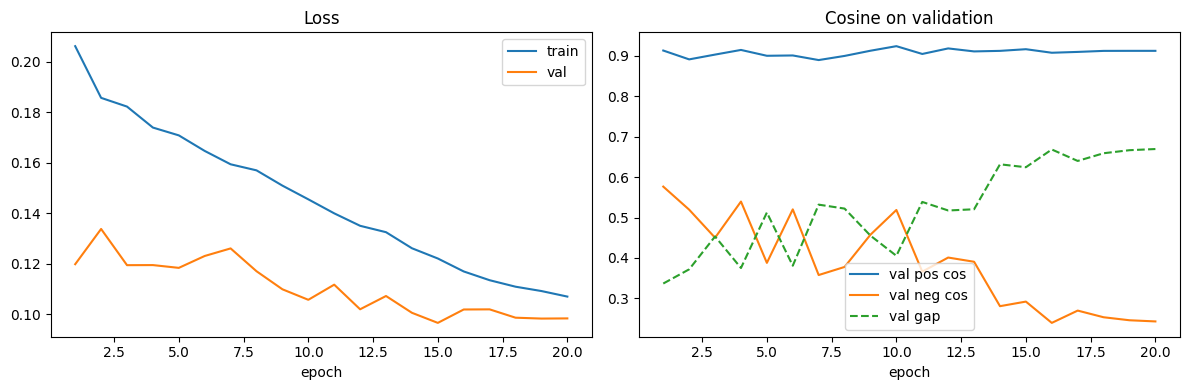

In [29]:
import matplotlib.pyplot as plt

hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
axes[0].plot(hist["epoch"], hist["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(hist["epoch"], hist["val_pos_cos"], label="val pos cos")
axes[1].plot(hist["epoch"], hist["val_neg_cos"], label="val neg cos")
axes[1].plot(hist["epoch"], hist["val_gap"],     label="val gap", linestyle="--")
axes[1].set_title("Cosine on validation"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## Test-set evaluation

Load the **best** checkpoint, compute cosine for every test pair and report:

- distribution of positive vs negative cosine,
- ROC-AUC (threshold-free quality),
- best threshold by F1 and the corresponding accuracy.

In [30]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, accuracy_score, f1_score

model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()

all_cos, all_lbl = [], []
with torch.no_grad():
    for a, b, label in tqdm(test_loader, desc="test"):
        a, b = a.to(DEVICE), b.to(DEVICE)
        ea, eb = model(a), model(b)
        cs = F.cosine_similarity(ea, eb).cpu().numpy()
        all_cos.extend(cs.tolist())
        all_lbl.extend(label.numpy().tolist())

all_cos = np.asarray(all_cos)
all_lbl = np.asarray(all_lbl)

auc = roc_auc_score(all_lbl, all_cos)

# best threshold by F1
prec, rec, thr = precision_recall_curve(all_lbl, all_cos)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1[:-1])) if len(thr) else 0
best_thr = float(thr[best_idx]) if len(thr) else 0.5
preds = (all_cos >= best_thr).astype(int)

print(f"ROC-AUC:     {auc:.4f}")
print(f"Best thr:    {best_thr:.4f}")
print(f"Accuracy@thr:{accuracy_score(all_lbl, preds):.4f}")
print(f"F1@thr:      {f1_score(all_lbl, preds):.4f}")
print(f"mean cos+:   {all_cos[all_lbl == 1].mean():.4f}")
print(f"mean cos-:   {all_cos[all_lbl == 0].mean():.4f}")

test:   0%|          | 0/14 [00:00<?, ?it/s]

ROC-AUC:     0.9197
Best thr:    0.4506
Accuracy@thr:0.9260
F1@thr:      0.9583
mean cos+:   0.9163
mean cos-:   0.2622


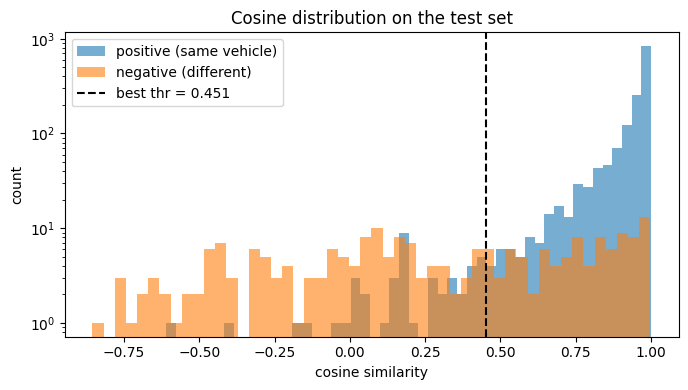

In [33]:
plt.figure(figsize=(7, 4))
plt.hist(all_cos[all_lbl == 1], bins=50, alpha=0.6, label="positive (same vehicle)")
plt.hist(all_cos[all_lbl == 0], bins=50, alpha=0.6, label="negative (different)")
plt.axvline(best_thr, color="k", linestyle="--", label=f"best thr = {best_thr:.3f}")
plt.xlabel("cosine similarity"); plt.ylabel("count"); plt.legend()
plt.title("Cosine distribution on the test set")
plt.tight_layout()
plt.yscale("log")
plt.show()

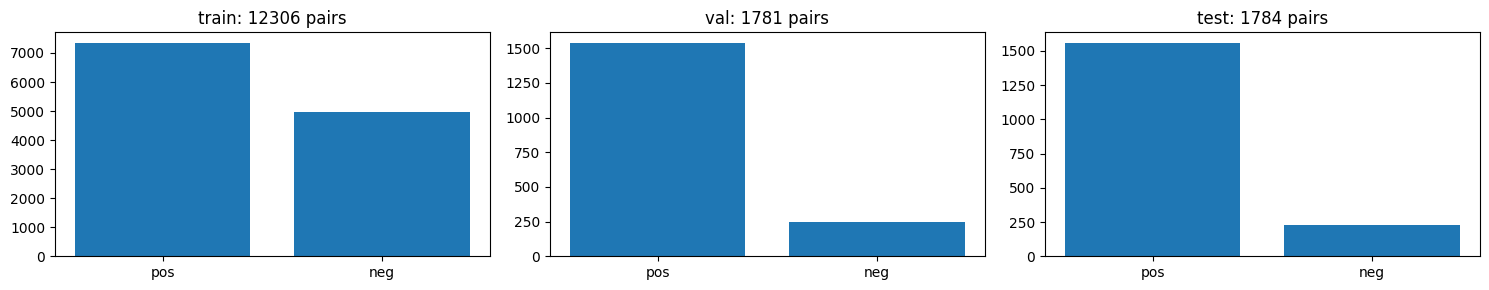

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (name, ds) in zip(axes, [("train", train_ds), ("val", val_ds), ("test", test_ds)]):
    df = ds.df
    ax.bar(["pos", "neg"], [(df["label"]==1).sum(), (df["label"]==0).sum()])
    ax.set_title(f"{name}: {len(df)} pairs")
plt.tight_layout(); plt.show()

In [32]:
import shutil

PROJECT_ROOT = Path("../..").resolve()
DEPLOY_PATH = PROJECT_ROOT / "encoder.pth"

shutil.copy(BEST_PATH, DEPLOY_PATH)
print(f"Deployed: {DEPLOY_PATH}")

Deployed: /encoder.pth


In [38]:
def encode(pil_img: Image.Image) -> np.ndarray:
    x = eval_tf(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        e = model(x).squeeze(0).cpu().numpy()
    return e

def cos(u, v):
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))

# Take a random positive and a random negative from the test CSV and compare
df_test = pd.read_csv(TEST_CSV)
sample_pos = df_test[df_test["label"] == 1].sample(1, random_state=SEED).iloc[0]
sample_neg = df_test[df_test["label"] == 0].sample(1, random_state=SEED).iloc[0]

for tag, s in [("POS", sample_pos), ("NEG", sample_neg)]:
    a = Image.open(DATA_ROOT / s["path_a"]).convert("RGB")
    b = Image.open(DATA_ROOT / s["path_b"]).convert("RGB")
    print(f"{tag}: cos = {cos(encode(a), encode(b)):.4f}  (label={int(s['label'])})")

POS: cos = 0.9891  (label=1)
NEG: cos = -0.7661  (label=0)


In [39]:
import shutil
shutil.make_archive("mlruns", "zip", './mlruns')
print("Done: mlruns.zip")

Done: mlruns.zip


In [40]:
model

Encoder(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (stage1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Identity()
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 6

In [41]:
%pip install -q huggingface_hub

In [43]:
from pathlib import Path
import shutil, torch

HF_REPO_DIR = Path("hf_repo").resolve()
HF_REPO_DIR.mkdir(exist_ok=True)

shutil.copy("configuration_vehicle_encoder.py", HF_REPO_DIR)
shutil.copy("modeling_vehicle_encoder.py",      HF_REPO_DIR)

# Импортировать наши классы
import sys; sys.path.insert(0, str(HF_REPO_DIR))
from configuration_vehicle_encoder import VehicleEncoderConfig
from modeling_vehicle_encoder      import VehicleEncoderModel

# Собрать HF-модель с нашими весами
config = VehicleEncoderConfig(
    latent_dim=LATENT_DIM,
    blocks_per_stage=2,
    img_size=IMG_SIZE,
)
hf_model = VehicleEncoderModel(config)

# Перекинуть веса из обучения
state_dict = torch.load(BEST_PATH, map_location="cpu")
missing, unexpected = hf_model.load_state_dict(state_dict, strict=False)
print("missing:", missing[:5], "unexpected:", unexpected[:5])
# Если оба пустые — отлично; имена слоёв совпадают.

# Прописать auto_map → HF поймёт что код модели лежит рядом
config.auto_map = {
    "AutoConfig": "configuration_vehicle_encoder.VehicleEncoderConfig",
    "AutoModel":  "modeling_vehicle_encoder.VehicleEncoderModel",
}
hf_model.config = config

# Сохранить в формате HF
hf_model.save_pretrained(HF_REPO_DIR, safe_serialization=True)

# Проверить локально
print(list(HF_REPO_DIR.iterdir()))

missing: [] unexpected: []


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[PosixPath('/content/hf_repo/modeling_vehicle_encoder.py'), PosixPath('/content/hf_repo/.ipynb_checkpoints'), PosixPath('/content/hf_repo/__pycache__'), PosixPath('/content/hf_repo/config.json'), PosixPath('/content/hf_repo/configuration_vehicle_encoder.py'), PosixPath('/content/hf_repo/model.safetensors')]


In [46]:
from huggingface_hub import HfApi
api = HfApi()
me = api.whoami()["name"]
for r in api.list_models(author=me):
    print(r.id)

quebeccyb/vehitv


In [48]:

from huggingface_hub import login, HfApi, create_repo

login()

REPO_ID = "quebeccyb/vehitv-cropped"

create_repo(REPO_ID, exist_ok=True, repo_type="model")

api = HfApi()
api.upload_folder(
    folder_path=str(HF_REPO_DIR),
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="add mini-resnet cosine encoder (cropped dataset)",
)
print(f"https://huggingface.co/{REPO_ID}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...hf_repo/model.safetensors:   1%|1         |  555kB / 45.3MB            

https://huggingface.co/quebeccyb/vehitv-cropped
